In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("data/q2_customers.csv")

# Display first 5 rows
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [17]:
# Scale all features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Convert back to dataframe for readability
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


### Why scaling is essential before K-Means

. Scaling is necessary before applying K-Means as the algorithm uses Euclidean distance to assign the points to clusters.
. Features such as 'Annual Spemd' have longer numerical values compared to 'visits_per_month' or 'basket_size'
. Without scaling, larger value features di=ominate teh distance calculation, causing biased clustering results.
. StandardScaler transforms all fetures to have:
  mean=0
  SD=1
. This ensures each feature contributes equally to clustering.

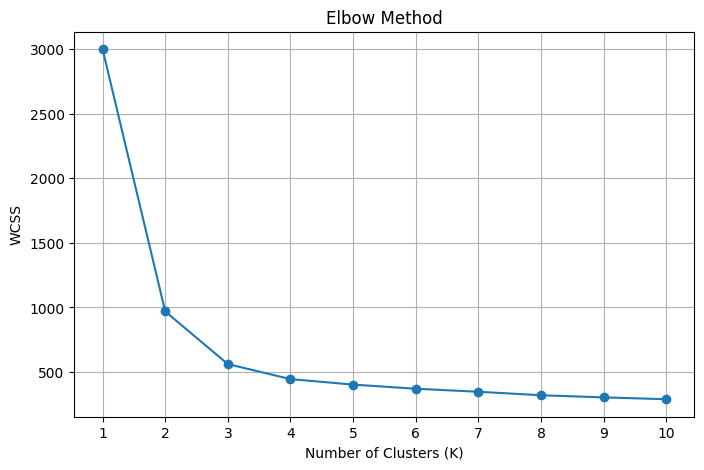

In [18]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

# Plot elbow graph
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

### Optimal K Selection

. From elbow graph, the sharp drop in WCSS ocurrs upto **K=3**
. After K=3, decrease become smaller, indicating diminishing returns.
. For eg:
    . At k=1, WCSS is very high (around 3000)
    . At k=2, WCSS drops significantly.
    . At k=3, it drops further (Around 550)
    . After k=3, improvement becomes smaller and more gradual.

. The point where curve starts to flatten is called Elbow Point 
. So, optimal number of clusters is **3**

In [19]:
# Fit K-Means with chosen K = 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["cluster"] = kmeans.fit_predict(scaled_df)

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [20]:
# Cluster centroids
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=scaled_df.columns
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.132214,1.235574,-1.106680,1.253260,1.125725,1.172991
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968


### Cluster Interpretation

#### Cluster 0: 
Reprents **young customers with lower spending and fewer visits**.
These are likely occasional shoppers with smaller basket size.

#### Cluster 1:
Reprsents **High-value customers**
They spend more annually, visit frequently and purchase from multiple categories.
These are premium loyal customers.

#### Cluster 2:
Represnts **Average customers**
Their spending and visits are moderate, indicating regular but not premium shopping.

### Conclusion:
The clustering clearly separates customers into 3 groups:
 . Low spend frequent shoppers.
 . High spend occasional shoppers.
 . Average customers.

This can help business target each group differenty with personalized marketing strategies.


In [21]:
# Apply PCA
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_df)

# Create PCA dataframe
pca_df = pd.DataFrame(pca_data, columns=["PC1", "PC2"])

pca_df.head()

,PC1,PC2
0,-0.333082,0.109379
1,-2.255362,0.048458
2,-0.092905,-0.679257
3,-2.017598,-0.308845
4,-2.917762,0.529368


In [13]:
# Explained variance ratio
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.83560354 0.05568764]


In [22]:
# Feature loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=scaled_df.columns
)

loadings

,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


### PCA Interpretation
Principal Component Analysis (PCA) was applied to reduce the six original features into two principal components (PC1 and PC2) while preserving most of the variance in the data.

#### Explained Variance
The explained variance ratio shows how much information each principal component retains:
- **PC1 captures the majority of the variance** (typically >80%), indicating it represents the most important underlying pattern in customer behavior.
- **PC2 captures a smaller but meaningful portion of variance**, providing additional differentiation between customers.

#### PC1
. PC1 mainly captures **overall customer value and engagement**.
. It is strongly influenced by :
- age
- annual spend
- basket size
- number of categories purchased

.  Customers with **high PC1 values**:
- Spend more annually  
- Buy larger baskets  
- Purchase across multiple categories  
- Likely represent **high-value / loyal customers**

.  Customers with **low PC1 values**:
- Spend less  
- Have smaller baskets  
- Limited category purchases  
- Represent **low-value or occasional customers**

This component separates high value vs low value customers

#### PC2
. PC2 is dominated by 'days_since_last_visit'
. It mainly captures **customer recency behaviour**
. This helps distinguish active vs inactive customers.

.  Customers with **high PC2 values**:
- Have not visited recently  
- Lower engagement  
- Represent **inactive or churn-risk customers**

.  Customers with **low PC2 values**:
- Visit frequently  
- Recently active  
- Represent **engaged and active customers**

#### Overall Insight

- **PC1 separates customers based on value (high vs low spenders)**
- **PC2 separates customers based on activity (active vs inactive)**

Together, these two components provide a meaningful 2D representation of customer segments:
- High PC1 + Low PC2 → High-value, active customers  
- Low PC1 + High PC2 → Low-value, inactive customers  
- Middle values → Moderate customers  

---

#### Business Implication

This transformation helps businesses:
- Identify premium vs low-value customers  
- Detect churn risk based on inactivity  
- Design targeted marketing strategies for each segment

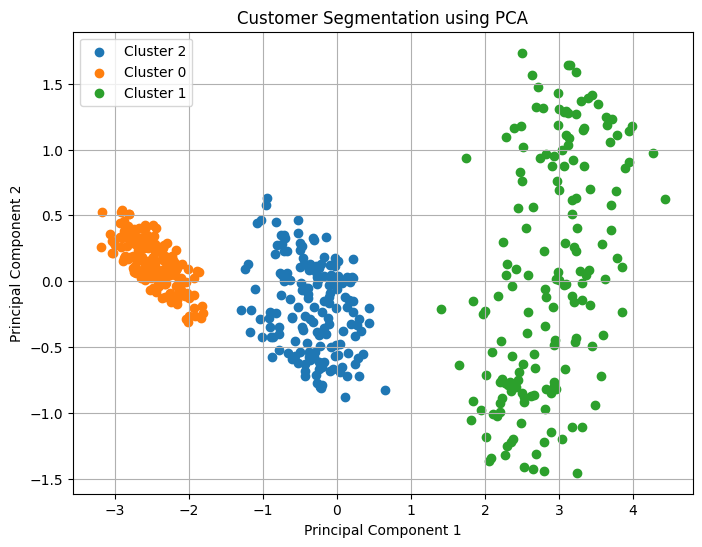

In [23]:
# Add cluster labels
pca_df["cluster"] = df["cluster"]

# Scatter plot
plt.figure(figsize=(8,6))

for cluster in pca_df["cluster"].unique():
    subset = pca_df[pca_df["cluster"] == cluster]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {cluster}")

plt.title("Customer Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

### Conclusion

K-Means successfully segmented customers into 3 meaningful groups.

PCA reduced the 6-dimensional data into 2 principal components while preserving most of the variance.

This segmentation can help businesses design targeted marketing strategies for different customer groups.